# Storage

*[CEGM1000 MUDE](http://mude.citg.tudelft.nl/)*

*Written by: Ronald Brinkgreve, Anna Störiko*

*Due: Wednesday, September 9, 2026.*

# Part 2: Numerical solution of a linear ODE

## Reservoir storage and discharge

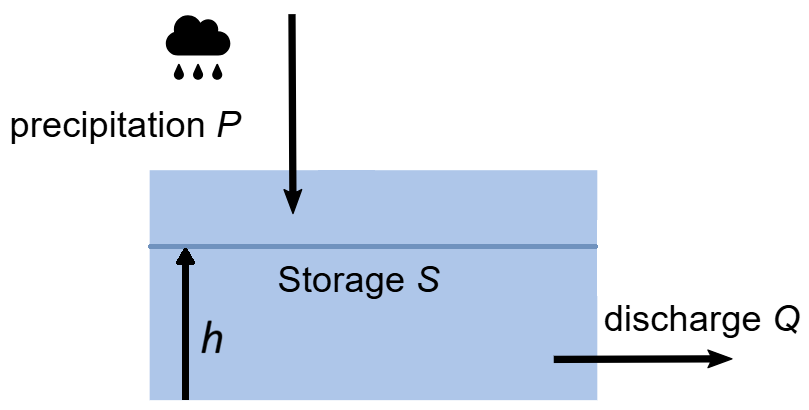

As a measure to cope with climate change, the municipality of a metropolis considers the construction of a big underground reservoir collecting rainwater for a part of the city as a buffer in periods of heavy rain, to prevent urban flooding. Above the minimum water level $h_{min}$, which acts as a reserve for the fire brigade to intake water for fire extinction, water can outflow the reservoir into the sewage system with reduced capacity. As a simplification, this outflow discharge is assumed proportional to the water level above the minimum level. Hence, the water level in the reservoir depends on both precipitation and discharge, while the latter is zero below the minimum level. If it rains heavily, the reservoir is filled up ($h$ will increase) and in case of little or no rain, the reservoir will empty ($h$ will decrease) down to the minimum level. The simplified system can be described by the following ordinary differential equation (ODE):

$$A_R\frac{dh}{dt} = A P(t)/1000 - K \left(h - h_{min} \right)$$

where:</p>
    $h$ is the water level in the reservoir</p>
    $t$ is the time</p>
    $A_R$ is the storage area of the reservoir</p>
    $A$ is the total area above ground from which precipitation is collected</p>
    $P(t)$ is the precipitation (measured on frequent regular time intervals in $mm/hour$)</p>
    $K$ is a term that defines the proportionality of the discharge with respect to the water level in $m^2/hour$

All areas are defined in $m^2$, while $h$ is defined in $m$ and $t$ in $hour$.

The maximum reservoir depth is 20 m. The idea is to design the size (base area) of the reservoir ($A_R$) based on a design precipitation scheme of 200 mm in 48 hours, using an initial estimate of 7000 $m^2$ (the size of a football field).

>
>**Task 2.1**
>
>Run the cells below to visualise the precipitation in the considered 48 hour time frame:
>

In [5]:
import matplotlib.pyplot as plt
import numpy as np

In [11]:
AR = 7000       # Reservoir's base area
A = 1000000     # Precipitation collection area (1 km^2)
K = 200         # Discharge factor
h_min = 2.0     # Minimum reservoir level

hours = 48
t_data = np.arange(1, hours + 1)

P_data = np.array([
    0, 10, 0, 5, 30, 0, 0, 4, 2, 0, 0, 0,
    80, 0, 0, 0, 0, 0, 14, 0, 3, 3, 0, 0,
    1, 4, 0, 0, 0, 0, 0, 0, 10, 34, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
])

(Alternatively, read an input file with precipitation data)

>
>**Task 2.2**
>
>Formulate the Forward Euler scheme for the above ODE and elaborate this into an expression for $h$ at the next time step ($h_{i+1}$).
>

Using the Forward Euler method,

$$
\frac{h_{i+1}-h_i}{\Delta t}
=
\frac{A P_i}{1000 A_R}
-
\frac{K}{A_R}(h_i-h_{\min})
$$

Therefore,

$$
h_{i+1}
=
h_i
+
\Delta t
\left(
\frac{A P_i}{1000 A_R}
-
\frac{K}{A_R}(h_i-h_{\min})
\right)
$$

>
>**Task 2.3**
>
>Complete and run the code cells below to calculate $h_{i+1}$ for all time steps until the end of the time interval, considering $h_0 = h_{min}$.


### Data initialisation

In [12]:
# Define the time step and create solution time points
dt = 0.1        # 0.1 hours = 6 minutes
num = int(hours / dt)
print(f"Number of time steps: {num}")
t = np.linspace(0, hours, num+1)

# Interpolate precipitation data to solution time points
indices = np.searchsorted(t_data, t, side='left')
P = P_data[indices]

assert len(P) == len(t)


Number of time steps: 480


### Forward Euler scheme

In [13]:
h = np.zeros_like(t)  # Create an array to store the reservoir level at each time step

h[0] = h_min

for i in range(num):
    h[i+1] = h[i] + dt * ((A * P[i]) / (1000 * AR) - (K / AR) * (h[i] - h_min))
    

>
>**Task 2.4**
>
>Run the code cell below to plot the results
>

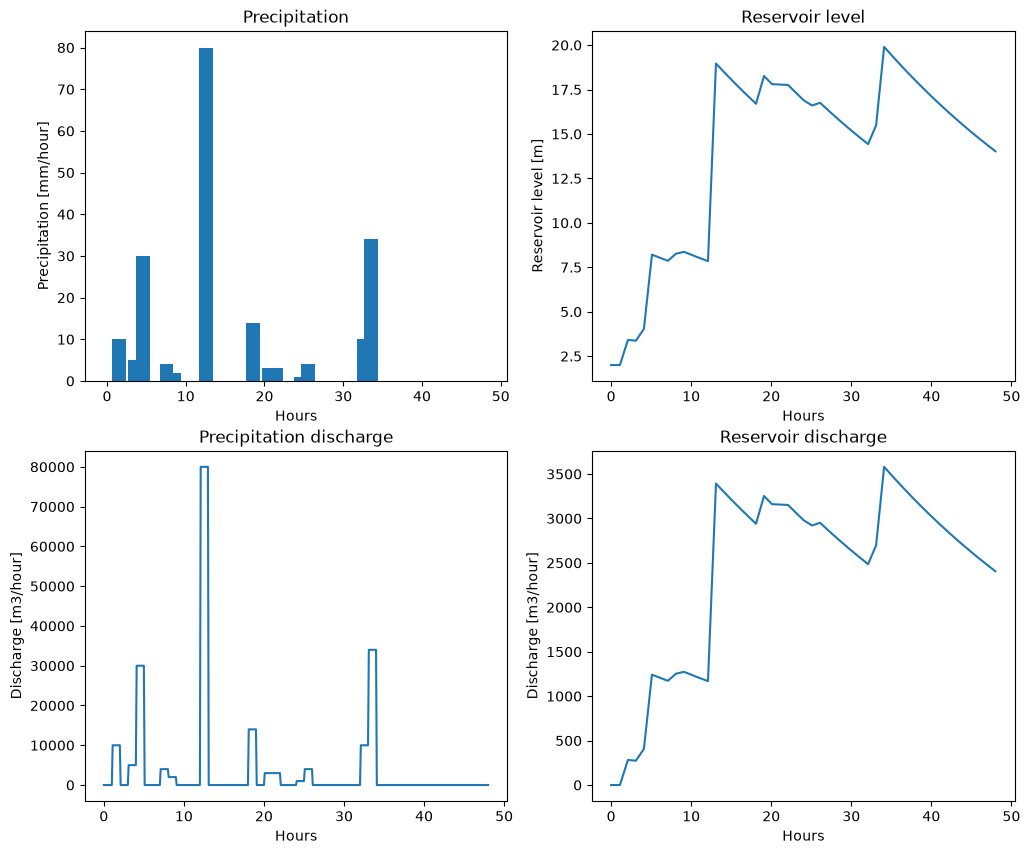

In [14]:
def plot_figs():
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

    ax[0,0].bar(t, P, label='Precipitation')
    ax[0,0].set_xlabel('Hours')
    ax[0,0].set_ylabel('Precipitation [mm/hour]')
    ax[0,0].set_title('Precipitation')

    ax[0,1].plot(t, h, label='Reservoir level')
    ax[0,1].set_xlabel('Hours')
    ax[0,1].set_ylabel('Reservoir level [m]')
    ax[0,1].set_title('Reservoir level')

    ax[1,0].plot(t, P*A/1000, label='Precipitation discharge')
    ax[1,0].set_xlabel('Hours')
    ax[1,0].set_ylabel('Discharge [m3/hour]')
    ax[1,0].set_title('Precipitation discharge')

    ax[1,1].plot(t, K*(h-h_min), label='Reservoir discharge')
    ax[1,1].set_xlabel('Hours')
    ax[1,1].set_ylabel('Discharge [m3/hour]')
    ax[1,1].set_title('Reservoir discharge')

plot_figs()

>
>**Task 2.5**
>
>Write a function (print_max()) to print the maximum values of:
>* The reservoir level
>* The maximum discharge flowing into the reservoir according to the design precipitation scheme
>* The maximum discharge from the reservoir
>

In [15]:
def print_max():
                print("Maximum reservoir level:", np.max(h), "m")
                print("Maximum precipitation discharge:", np.max(A * P / 1000), "m3/hour")
                print("Maximum reservoir discharge:", np.max(K * (h - h_min)), "m3/hour")

print_max()

Maximum reservoir level: 19.90239477736076 m
Maximum precipitation discharge: 80000.0 m3/hour
Maximum reservoir discharge: 3580.4789554721524 m3/hour


>
>**Task 2.6**
>
>Verify (analytically) the stability of the Forward Euler solution. Give the expression for the condition of stability. 
>

For the Forward Euler method, the amplification factor is

$$
1-\Delta t\frac{K}{A_R}
$$

For stability,

$$
\left|1-\Delta t\frac{K}{A_R}\right|<1
$$

Therefore,

$$
0<\Delta t<\frac{2A_R}{K}
$$

With $A_R = 7000\,\mathrm{m}^2$ and $K = 200\,\mathrm{m}^2/\mathrm{hour}$,

$$
\Delta t<70\text{ hours}
$$

Since $\Delta t=0.1$ hours, the Forward Euler solution is stable.

>
>**Task 2.7**
>
>Formulate the Backward (Implicit) Euler scheme for the above ODE and elaborate this into an expression for $h$ at the next time step ($h_{i+1}$).
>
>Hints: 
>* Refer to next week's lecture or Section 1.2 in the book for an application of the Backward Euler scheme:
>* It may be useful to introduce $h^*$ as an offset to $h$ considering $h_{min}$:
>
>$$h^* = h - h_{min} $$

Using the Backward Euler method,

$$
\frac{h_{i+1}-h_i}{\Delta t}
=
\frac{A P_{i+1}}{1000A_R}
-
\frac{K}{A_R}(h_{i+1}-h_{\min})
$$

Introducing

$$
h^*=h-h_{\min},
$$

the scheme becomes

$$
\frac{h^*_{i+1}-h^*_i}{\Delta t}
=
\frac{A P_{i+1}}{1000A_R}
-
\frac{K}{A_R}h^*_{i+1}.
$$

Solving for the next time step gives

$$
h^*_{i+1}
=
\frac{
h^*_i+\Delta t\frac{A P_{i+1}}{1000A_R}
}{
1+\Delta t\frac{K}{A_R}
}.
$$

Therefore,

$$
h_{i+1}
=
h_{\min}
+
\frac{
h_i-h_{\min}+\Delta t\frac{A P_{i+1}}{1000A_R}
}{
1+\Delta t\frac{K}{A_R}
}.
$$

>
>**Task 2.8**
>    
>Complete and run the code cell below to calculate $h_{i+1}$ for all time steps until the end of the time interval using the Backward Euler scheme.
>

### Backward Euler scheme

In [16]:
h_star = np.zeros_like(t)

h_star[0] = 0.0

for i in range(num):
    h_star[i+1] = (
        h_star[i] + dt * (A * P[i+1]) / (1000 * AR)
    ) / (
        1 + dt * K / AR
    )

h = h_min + h_star

Plotting the results

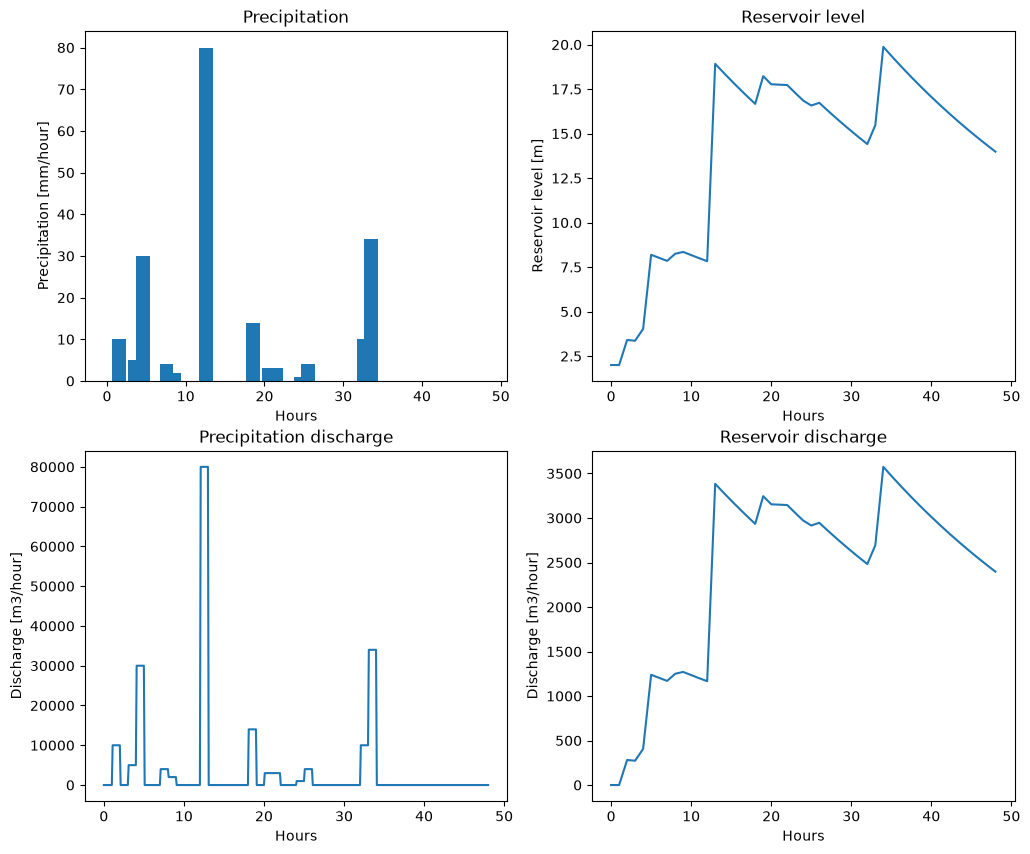

In [17]:
plot_figs()

printing the maximum values

In [ ]:
print_max()

Maximum reservoir level         : 19.54 m
Maximum precipitation discharge : 80000 m3/hour
Maximum reservoir discharge     : 3509 m3/hour


>
>**Task 2.9**
>
>Comment on the suitability of the reservoir in terms of:
>* Its capacity in view of the design precipitation scheme
>* Its capacity in view of the total design precipitation in 48 hours (what if the precipitation distribution over 48 hours is different?)
>* Its function to act as a buffer preventing overflow of the sewage system
>
>What would you advise the municipality?
>

The reservoir is able to handle the given design precipitation scheme, since the maximum reservoir level is about 19.54 m, which is below the maximum depth of 20 m. However, the remaining safety margin is small.

Although the total precipitation is 200 mm over 48 hours, the timing and distribution of the rainfall are also important. If the same amount of rain falls in a shorter period or with higher peak intensities, the reservoir level could exceed 20 m.

The reservoir can reduce the peak flow entering the sewage system by temporarily storing water and releasing it more gradually. However, because the reservoir is already close to its maximum level during the given design event, its buffering capacity is limited.

I would advise the municipality to increase the reservoir capacity or provide an additional safety margin. The design should also be tested with different rainfall distributions, especially more concentrated and extreme rainfall events, before construction.

> By Ronald Brinkgreve and Anna Störiko, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2025/credits.html).